## Furniture Price Prediction (IKEA Dataset)

### Goal
Analyze factors influencing furniture prices and build a machine learning model to predict price.

### Imports

In [193]:
import pandas as pd
import numpy as np
import matplotlib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import joblib

### Load Data

In [194]:
# load dataset and remove duplicates
df = pd.read_csv('data/ikea.csv', sep = ',', index_col=0).drop_duplicates()
df.head()

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0


## Exploratory Data Analysis with Descriptive Statistics and Visualizations

In [195]:
print("Shape of dataframe:", df.shape)
print("Columns names:", df.columns)

# Check missing values
df.info()

print("Missing values per column:")
print(df.isnull().sum())

Shape of dataframe: (3694, 13)
Columns names: Index(['item_id', 'name', 'category', 'price', 'old_price', 'sellable_online',
       'link', 'other_colors', 'short_description', 'designer', 'depth',
       'height', 'width'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 3694 entries, 0 to 3693
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            3694 non-null   int64  
 1   name               3694 non-null   object 
 2   category           3694 non-null   object 
 3   price              3694 non-null   float64
 4   old_price          3694 non-null   object 
 5   sellable_online    3694 non-null   bool   
 6   link               3694 non-null   object 
 7   other_colors       3694 non-null   object 
 8   short_description  3694 non-null   object 
 9   designer           3694 non-null   object 
 10  depth              2231 non-null   float64
 11  height             270

We can see that missing values are mainly in product dimensions

### Data Cleaning

In [196]:
# remove columns that are not useful for analysis
df = df.drop(['item_id', 'link'], axis=1)

# remove rows with missing values (simple approach)
# in production, missing values would be handled using imputation
df = df.dropna()

# convert categorical feature to numeric
df["other_colors"] = df["other_colors"].map({'Yes': 1, 'No': 0})

df.head()

,name,category,price,old_price,sellable_online,other_colors,short_description,designer,depth,height,width
3,STIG,Bar furniture,69.0,No old price,True,1,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,NORBERG,Bar furniture,225.0,No old price,True,0,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
5,INGOLF,Bar furniture,345.0,No old price,True,0,"Bar stool with backrest, 63 cm",Carina Bengs,45.0,91.0,40.0
6,FRANKLIN,Bar furniture,129.0,No old price,True,0,"Bar stool with backrest, foldable, ...",K Hagberg/M Hagberg,44.0,95.0,50.0
8,FRANKLIN,Bar furniture,129.0,No old price,True,0,"Bar stool with backrest, foldable, ...",K Hagberg/M Hagberg,44.0,95.0,50.0


### Categories understanding

In [197]:
# Explore category distribution
print("Unique categories:", df['category'].nunique())
print(df['category'].value_counts())

Unique categories: 17
category
Bookcases & shelving units              375
Sofas & armchairs                       223
Chairs                                  213
Wardrobes                               199
Cabinets & cupboards                    199
Chests of drawers & drawer units        121
Tables & desks                          103
TV & media furniture                     95
Outdoor furniture                        81
Beds                                     78
Children's furniture                     78
Nursery furniture                        62
Bar furniture                            24
Sideboards, buffets & console tables     20
Café furniture                           13
Trolleys                                  9
Room dividers                             6
Name: count, dtype: int64


The dataset contains 17 product categories.
The distribution is imbalanced — some categories (e.g. Bookcases & shelving units, Chairs) contain significantly more items than others. 
This may influence the model, as categories with more data can dominate learning.

### Feature Engineering

In [198]:
# create new feature: product volume
df['volume'] = df['depth'] * df['height'] * df['width']

I introduced a new feature — volume — to capture the physical size of the product, which may better explain price and category than individual dimensions.

### Feature Importance

Using `sklearn.feature_selection` library

In [199]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression # mutual_info_classif -- for discrete data, mutual_info_regression-- for continuous data

# Relationship with category
X_cat = df[['price', 'volume']]
y_cat = df['category']

importance_cat = mutual_info_classif(X_cat, y_cat)
pd.Series(importance_cat, index=X_cat.columns)

price     0.358783
volume    0.632569
dtype: float64

Volume shows a stronger relationship with category than price, which suggests that product size is a key factor in how items are grouped.

In [200]:
# Relationship with price
X_price = df[['depth', 'height', 'width']]
y_price = df['price']

importance_price = mutual_info_regression(X_price, y_price)
pd.Series(importance_price, index=X_price.columns)

depth     0.614440
height    0.691583
width     0.896409
dtype: float64

Width appears to have the strongest relationship with price among dimensions, suggesting that wider products tend to be more expensive.

### Distribution analysis

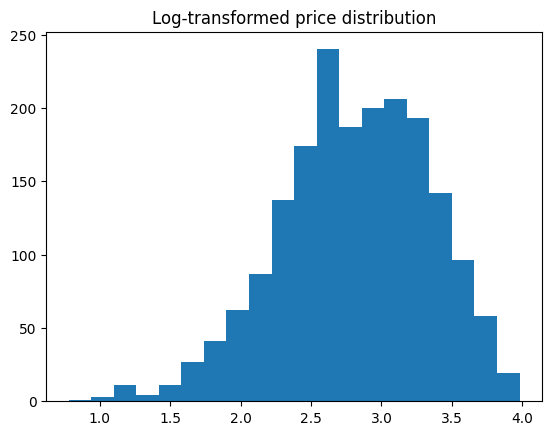

In [201]:
import matplotlib.pyplot as plt

plt.hist(np.log10(df['price']), bins=20)
plt.title("Log-transformed price distribution")
plt.show()

The price distribution is right-skewed. After log transformation, it becomes more symmetric, but still deviates from a normal distribution.

## Hypothesis testing


Based on the above data analysis, I formulate the following hypothesis:

***H0: There is no difference in price between products with one color and multiple colors.***

Since the price distribution is not normal, The Mann–Whitney U test is used.

In [202]:
import scipy.stats as sps

one_color = df[df['other_colors'] == 0]['price']
multi_color = df[df['other_colors'] == 1]['price']

stat, p_value = sps.mannwhitneyu(one_color, multi_color)
print("p-value:", p_value)

p-value: 1.0015089882617485e-21


***Result:***
p-value < 0.05 → reject H0.

***Conclusion:***
There is a statistically significant difference in price depending on whether a product has multiple colors.

## Furniture Price Prediction

The goal of this section is to build a model that predicts product price based on product characteristics.

Before modeling, I selected features that are meaningful and available at prediction time.

### Feature selection

In [203]:
# select features for modeling
X = df[['depth', 'width', 'height', 'volume', 'category', 'other_colors']]
y = df['price']

I excluded columns such as `item_id` and `link`, as they are unique identifiers and do not provide predictive value.

Text fields like `name` or `short_description` were also excluded, as they require additional preprocessing.

The selected features represent physical product properties and category, which are expected to influence price.

### Train-test split

In [204]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# split data into training and testing sets, size of sample=20%
#i.e.80/20 - Pareto principle: for many phenomena 80 percent of the effects are caused by 20 percent of the causes, ex. 20 % of buyers give 80 % of the profits.

### Pipeline

In [205]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# feature groups
numeric_features = ['depth', 'width', 'height', 'volume', 'other_colors']
categorical_features = ['category']

# Numeric preprocessing
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Final model pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

All preprocessing steps are included in the pipeline. 

This ensures that the same transformations are applied during both training and inference, and allows the model to work directly with raw input data.

This design also simplifies deployment, as no additional preprocessing logic is required outside the model.

### Train model

In [206]:
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation

In [207]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model_pipeline.predict(X_test)

print("Sample predictions:")
print(preds[:5])

print("R^2:", r2_score(y_test, preds))  # R2 quantify how well a regression model fits a dataset
print("MAE:", mean_absolute_error(y_test, preds)) # Mean Absolute Error (MAE)

Sample predictions:
[ 269.44733333  421.8        1071.15         68.845      2180.27      ]
R^2: 0.8664209585386335
MAE: 350.4227622188055


The model provides a baseline performance for price prediction.

The model achieves R^2 = 0.866, which indicates that it explains around 86.6% of the variance in product prices. 
This suggests that the selected features (dimensions and category) capture most of the underlying patterns in the data.

The Mean Absolute Error (MAE) is approximately 350, which means that on average, the model's predictions differ from the actual price by about 350 units.

Considering the wide price range across different product categories (e.g. small items vs large furniture), this level of error is reasonable and expected.

Overall, the error indicates that while the model captures general trends, there is still room for improvement, especially due to limited features.

### Save model

In [208]:
joblib.dump(model_pipeline, "model.pkl")

['model.pkl']

### Conclusion and potential improvements

- Product dimensions influence price
- Category also plays an important role
- The model can estimate furniture prices with reasonable accuracy
- Pipeline allows using raw data directly, which simplifies deployment

Potential improvements:

- Use additional features (e.g. designer)
- Apply more advanced models (e.g. `Gradient Boosting`, `XGBoost`)
- Perform hyperparameter tuning
- Include feature engineering (e.g. volume, price per dimension)
- Collect more balanced data across categories